# Trains and compares YOLO26n/s/m-seg on the final, leak-free, duplicate-free, already-balanced tooth instance-segmentation dataset (Dataset Tratado 1 Segmentacion). Replaces the three separate pipeline_YOLO26{n,s,m}_dientes.md notebooks. Generates article Table 10/11 (cross-variant comparison), training curves, per-class mAP50, and saves all three best.pt files.

**Design change vs. the previous version of this notebook (resilience to
Colab disconnects):** training used to run in a single loop over the three
variants, in memory, saving everything to Drive only at the very end. If
Colab disconnected mid-run (as happened at epoch 111/150 of `yolo26n-seg`),
**all progress for all three variants was lost**, because the local
`/content/runs` folder is wiped when the runtime resets.

This version fixes that with three changes:

1. **One independent cell per variant** (5A = nano, 5B = small, 5C = medium).
   Each cell is self-contained: it does not depend on variables created by a
   previous cell in the same runtime session, because a disconnect resets
   the whole session. Each cell reloads whatever it needs from Drive.
2. **Periodic checkpoint sync to Drive during training**, via an Ultralytics
   callback that copies `last.pt` (every `CHECKPOINT_EVERY` epochs) and
   `best.pt` (whenever it improves) to a per-variant folder in Drive. If
   Colab disconnects at epoch 111, the checkpoint from the last synced
   epoch is already safely in Drive, not lost with the runtime.
3. **Resume detection**: each variant's cell checks Drive first. If a
   final `best.pt` for that variant already exists, it skips training
   entirely (already done). If only a mid-training checkpoint exists, it
   resumes training from that checkpoint instead of starting from epoch 0.
   This means you can now run cell 5A, let it finish, close the tab, come
   back later and run 5B, and a disconnect during 5B never touches the
   already-saved 5A results.

Run the three training cells (5A, 5B, 5C) **one at a time**, waiting for
each to print `✅ <variant> saved to Drive` before moving to the next. You
do not have to run them in the same sitting.

## CELL 0 — Environment check and installation

In [ ]:
import subprocess
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"],
                      capture_output=True, text=True).stdout)

name, memory.total [MiB]
Tesla T4, 15360 MiB



In [ ]:
!pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.3 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import os
import shutil
import time
import glob
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

print("CUDA disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "ninguna — revisa el entorno de ejecución")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA disponible: True
GPU: Tesla T4


## CELL 1 — Route configuration

In [ ]:
BASE_DIENTES = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES")
DATASET_ROOT = BASE_DIENTES / "Dataset Tratado 1 Segmentacion"
DATA_YAML = DATASET_ROOT / "data.yaml"

RUNS_DRIVE = BASE_DIENTES / "runs_segmentacion_dientes"
RUNS_DRIVE.mkdir(parents=True, exist_ok=True)

# Per-variant checkpoint folders — synced periodically DURING training,
# not only at the end. This is what survives a Colab disconnect.
CHECKPOINTS_DRIVE = BASE_DIENTES / "checkpoints_segmentacion_dientes"
CHECKPOINTS_DRIVE.mkdir(parents=True, exist_ok=True)

MODELOS_DRIVE = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO DIENTES")
MODELOS_DRIVE.mkdir(parents=True, exist_ok=True)

FIGURAS_DRIVE = BASE_DIENTES / "figuras_segmentacion_dientes"
FIGURAS_DRIVE.mkdir(parents=True, exist_ok=True)

assert DATA_YAML.exists(), (
    f"No se encontró {DATA_YAML} — corre primero "
    "Tratado_1_dataset_Segmentacion_Dientes.md (incluye exclusión cross-stage, "
    "dedup por hash y oversampling de '3rd Molar')."
)
print("data.yaml:", DATA_YAML)
print(DATA_YAML.read_text())

CLASS_NAMES = ['1st Molar', '1st Premolar', '2nd Molar', '2nd Premolar',
               '3rd Molar', 'Canine', 'Central Incisor', 'Lateral Incisor']

CHECKPOINT_EVERY = 10   # epochs between periodic last.pt syncs to Drive

data.yaml: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/Dataset Tratado 1 Segmentacion/data.yaml
names:
- 1st Molar
- 1st Premolar
- 2nd Molar
- 2nd Premolar
- 3rd Molar
- Canine
- Central Incisor
- Lateral Incisor
nc: 8
path: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/Dataset Tratado 1 Segmentacion
test: test/images
train: train/images
val: valid/images



## CELL 2 — Copy the dataset into Colab local storage (faster training)

The dataset copied here is the **final** one: cross-stage patients already
excluded, groups already verified duplicate-free, and `train` already
containing the '3rd Molar' oversampled copies. Re-run this cell after any
disconnect — it is idempotent (skips the copy if `/content/dataset` already
exists in the current runtime).

In [ ]:
dst = Path("/content/dataset")
if not dst.exists():
    print("Copiando dataset...")
    shutil.copytree(DATASET_ROOT, dst)
    print("✅ Copia completada")
else:
    print("Dataset ya presente en este runtime, no se vuelve a copiar.")

yaml_content = f"""names:
{chr(10).join(f'- {c}' for c in CLASS_NAMES)}
nc: {len(CLASS_NAMES)}
path: /content/dataset
test: test/images
train: train/images
val: valid/images
"""
(dst / "data.yaml").write_text(yaml_content)
DATA_YAML_LOCAL = dst / "data.yaml"

for split in ["train", "valid", "test"]:
    imgs = list((dst / split / "images").glob("*"))
    lbls = list((dst / split / "labels").glob("*.txt"))
    print(f"{split}: {len(imgs)} imágenes | {len(lbls)} labels")

Copiando dataset...
✅ Copia completada
train: 2363 imágenes | 2363 labels
valid: 284 imágenes | 284 labels
test: 244 imágenes | 244 labels


## CELL 3 — Class distribution check (informational only — no augmentation here)

In [ ]:
ids = set()
for f in glob.glob(str(dst / "train" / "labels" / "*.txt")):
    for line in open(f):
        if line.strip():
            ids.add(int(line.split()[0]))
print(f"Total de clases presentes en train: {len(ids)}")
print(f"IDs encontrados: {sorted(ids)}")

counter = Counter()
n_aug3m = 0
for f in glob.glob(str(dst / "train" / "labels" / "*.txt")):
    if '_aug3M_' in f:
        n_aug3m += 1
    with open(f) as file:
        for line in file:
            if line.strip():
                counter[int(line.split()[0])] += 1

print("\nInstancias por clase en train (ya incluye el oversampling de Tratado_1):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:20s}: {counter.get(i, 0)}")
print(f"\nArchivos de train que son copias oversampled ('_aug3M_'): {n_aug3m}")

Total de clases presentes en train: 8
IDs encontrados: [0, 1, 2, 3, 4, 5, 6, 7]

Instancias por clase en train (ya incluye el oversampling de Tratado_1):
  1st Molar           : 4847
  1st Premolar        : 5209
  2nd Molar           : 4215
  2nd Premolar        : 4451
  3rd Molar           : 1986
  Canine              : 5732
  Central Incisor     : 5960
  Lateral Incisor     : 5802

Archivos de train que son copias oversampled ('_aug3M_'): 1140


## CELL 4 — Common hyperparameters and helper functions (run before ANY of 5A/5B/5C)

Same protocol as the detection pipeline: identical hyperparameters for
n/s/m, only `batch` adjusted per variant. The helper functions below are
what make each variant's cell self-contained and resumable.

In [ ]:
EPOCHS = 150
PATIENCE = 30
IMGSZ = 640
OPTIMIZER = "AdamW"
LR0 = 0.001
LRF = 0.01
MOMENTUM = 0.937
WEIGHT_DECAY = 0.0005
SEED = 0

AUG_COMUN = dict(
    fliplr=0.5, flipud=0.1, mosaic=1.0, mixup=0.1,
    degrees=10.0, translate=0.1, scale=0.5, shear=2.0,
)

VARIANTES = {
    "yolo26n-seg": {"yaml": "yolo26n-seg.yaml", "batch": 8},
    "yolo26s-seg": {"yaml": "yolo26s-seg.yaml", "batch": 8},
    "yolo26m-seg": {"yaml": "yolo26m-seg.yaml", "batch": 4},
}

for nombre, cfg in VARIANTES.items():
    print(f"  {nombre}: yaml={cfg['yaml']}, batch={cfg['batch']}, epochs={EPOCHS}, "
          f"imgsz={IMGSZ}, patience={PATIENCE}, lr0={LR0}")


def ruta_checkpoint_drive(nombre_variante: str) -> Path:
    carpeta = CHECKPOINTS_DRIVE / nombre_variante
    carpeta.mkdir(parents=True, exist_ok=True)
    return carpeta


def ya_esta_completo(nombre_variante: str) -> bool:
    """True if this variant's FINAL best.pt is already saved in MODELO DIENTES."""
    return (MODELOS_DRIVE / f"{nombre_variante}_best.pt").exists()


def checkpoint_existente(nombre_variante: str):
    """Returns the path to a mid-training last.pt in Drive, if any, else None."""
    carpeta = ruta_checkpoint_drive(nombre_variante)
    last_pt = carpeta / "last.pt"
    return last_pt if last_pt.exists() else None


def hacer_callback_sync_drive(nombre_variante: str):
    """Builds an Ultralytics callback that copies last.pt to Drive every
    CHECKPOINT_EVERY epochs, and best.pt to Drive whenever it is updated —
    so a Colab disconnect never loses more than CHECKPOINT_EVERY epochs of
    progress."""
    carpeta_drive = ruta_checkpoint_drive(nombre_variante)

    def on_fit_epoch_end(trainer):
        epoch_actual = trainer.epoch + 1
        local_last = trainer.save_dir / "weights" / "last.pt"
        local_best = trainer.save_dir / "weights" / "best.pt"

        if local_best.exists():
            shutil.copy(local_best, carpeta_drive / "best.pt")

        if epoch_actual % CHECKPOINT_EVERY == 0 and local_last.exists():
            shutil.copy(local_last, carpeta_drive / "last.pt")
            print(f"  💾 Checkpoint sincronizado a Drive (epoch {epoch_actual}): {carpeta_drive}")

    return on_fit_epoch_end


def entrenar_variante(nombre_variante: str):
    """Trains (or resumes) a single variant, syncing checkpoints to Drive
    throughout, and saves the final artifacts to MODELO DIENTES on success.
    Safe to call again after a disconnect: skips if already complete."""

    if ya_esta_completo(nombre_variante):
        print(f"✅ {nombre_variante} ya está completo en Drive — no se re-entrena.")
        print(f"   {MODELOS_DRIVE / f'{nombre_variante}_best.pt'}")
        return

    cfg = VARIANTES[nombre_variante]
    checkpoint_previo = checkpoint_existente(nombre_variante)

    print(f"\n{'='*60}\nEntrenando {nombre_variante}\n{'='*60}")
    t0 = time.time()

    if checkpoint_previo is not None:
        print(f"🔁 Checkpoint encontrado en Drive — reanudando desde: {checkpoint_previo}")
        local_resume = Path("/content") / f"resume_{nombre_variante}.pt"
        shutil.copy(checkpoint_previo, local_resume)
        modelo = YOLO(str(local_resume))
        callback = hacer_callback_sync_drive(nombre_variante)
        modelo.add_callback("on_fit_epoch_end", callback)
        resultado = modelo.train(resume=True)
    else:
        print("▶️ No hay checkpoint previo — entrenando desde cero.")
        modelo = YOLO(cfg["yaml"])
        callback = hacer_callback_sync_drive(nombre_variante)
        modelo.add_callback("on_fit_epoch_end", callback)
        resultado = modelo.train(
            data=str(DATA_YAML_LOCAL),
            epochs=EPOCHS,
            imgsz=IMGSZ,
            batch=cfg["batch"],
            pretrained=False,
            project="runs/dientes",
            name=nombre_variante,
            patience=PATIENCE,
            device="cuda:0",
            optimizer=OPTIMIZER,
            lr0=LR0,
            lrf=LRF,
            momentum=MOMENTUM,
            weight_decay=WEIGHT_DECAY,
            **AUG_COMUN,
            cos_lr=True,
            close_mosaic=15,
            seed=SEED,
            val=True,
            verbose=True,
        )

    tiempo_entrenamiento = time.time() - t0
    save_dir = Path(resultado.save_dir)
    ruta_best = save_dir / "weights" / "best.pt"
    ruta_last = save_dir / "weights" / "last.pt"

    # --- Save final artifacts to Drive immediately, before moving to the next variant ---
    if ruta_best.exists():
        shutil.copy(ruta_best, MODELOS_DRIVE / f"{nombre_variante}_best.pt")
    if ruta_last.exists():
        shutil.copy(ruta_last, MODELOS_DRIVE / f"{nombre_variante}_last.pt")

    cm_path = save_dir / "confusion_matrix.png"
    if cm_path.exists():
        shutil.copy(cm_path, MODELOS_DRIVE / f"confusion_matrix_{nombre_variante}.png")

    results_csv = save_dir / "results.csv"
    if results_csv.exists():
        shutil.copy(results_csv, RUNS_DRIVE / f"results_{nombre_variante}.csv")

    with open(RUNS_DRIVE / f"tiempo_entrenamiento_{nombre_variante}.txt", "w") as f:
        f.write(f"{tiempo_entrenamiento/60:.2f} minutos\n")

    # Clean up the mid-training checkpoint now that the final model is safely saved
    carpeta_checkpoint = ruta_checkpoint_drive(nombre_variante)
    if (carpeta_checkpoint / "last.pt").exists():
        (carpeta_checkpoint / "last.pt").unlink()

    print(f"\n✅ {nombre_variante} saved to Drive "
          f"({tiempo_entrenamiento/60:.1f} min): {MODELOS_DRIVE / f'{nombre_variante}_best.pt'}")

  yolo26n-seg: yaml=yolo26n-seg.yaml, batch=8, epochs=150, imgsz=640, patience=30, lr0=0.001
  yolo26s-seg: yaml=yolo26s-seg.yaml, batch=8, epochs=150, imgsz=640, patience=30, lr0=0.001
  yolo26m-seg: yaml=yolo26m-seg.yaml, batch=4, epochs=150, imgsz=640, patience=30, lr0=0.001


## CELL 5A — Train yolo26n-seg (run independently; safe to stop/resume)

In [ ]:
entrenar_variante("yolo26n-seg")

✅ yolo26n-seg ya está completo en Drive — no se re-entrena.
   /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO DIENTES/yolo26n-seg_best.pt


## CELL 5B — Train yolo26s-seg (run only after 5A prints ✅; safe to stop/resume)

In [ ]:
entrenar_variante("yolo26s-seg")

✅ yolo26s-seg ya está completo en Drive — no se re-entrena.
   /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/MODELO DIENTES/yolo26s-seg_best.pt


## CELL 5C — Train yolo26m-seg (run only after 5B prints ✅; safe to stop/resume)

In [10]:
entrenar_variante("yolo26m-seg")


Entrenando yolo26m-seg
🔁 Checkpoint encontrado en Drive — reanudando desde: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/checkpoints_segmentacion_dientes/yolo26m-seg/last.pt
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=F

## CELL 6 — Training curves by metric (loss, mAP50, precision, recall) — one figure per variant

Reads `results.csv` **from Drive**, not from an in-memory dict — so this
works even if you trained the three variants across separate Colab
sessions.

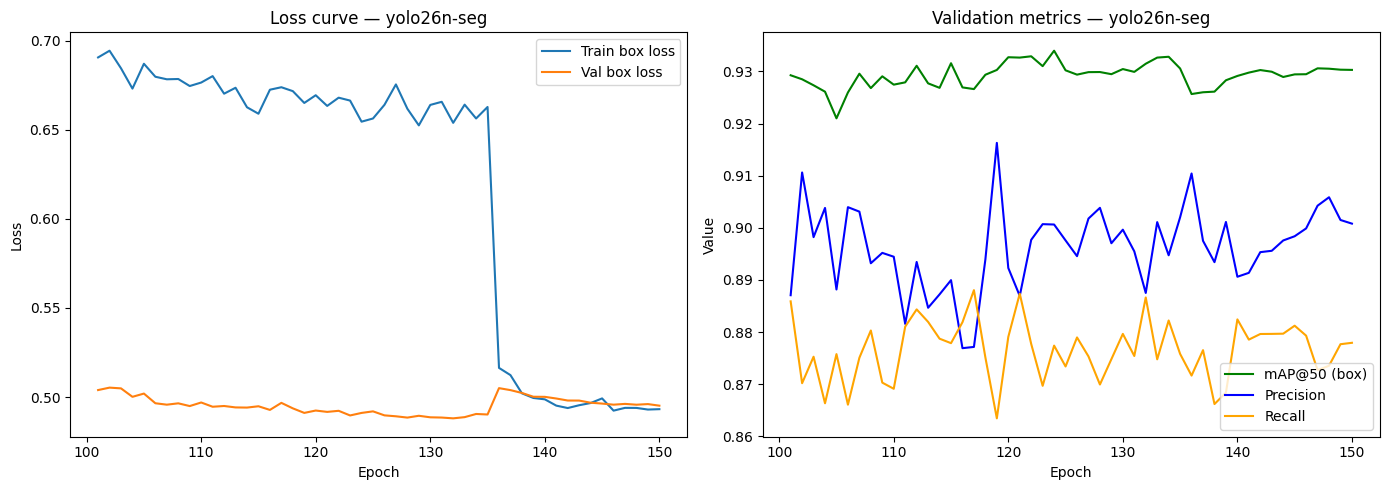

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/figuras_segmentacion_dientes/curvas_entrenamiento_yolo26n-seg.png


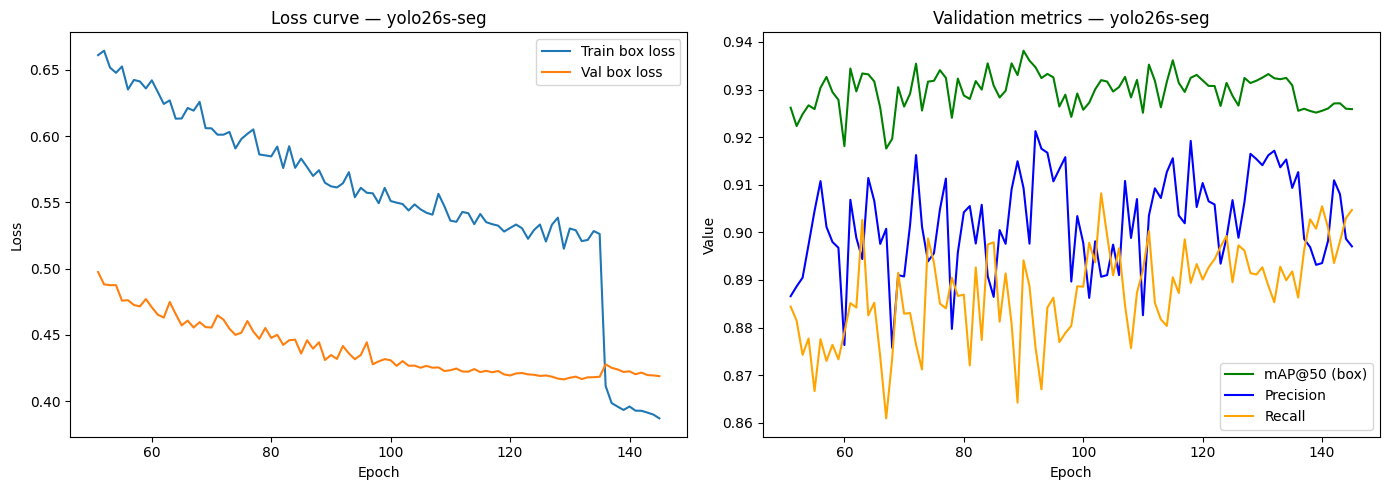

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/figuras_segmentacion_dientes/curvas_entrenamiento_yolo26s-seg.png


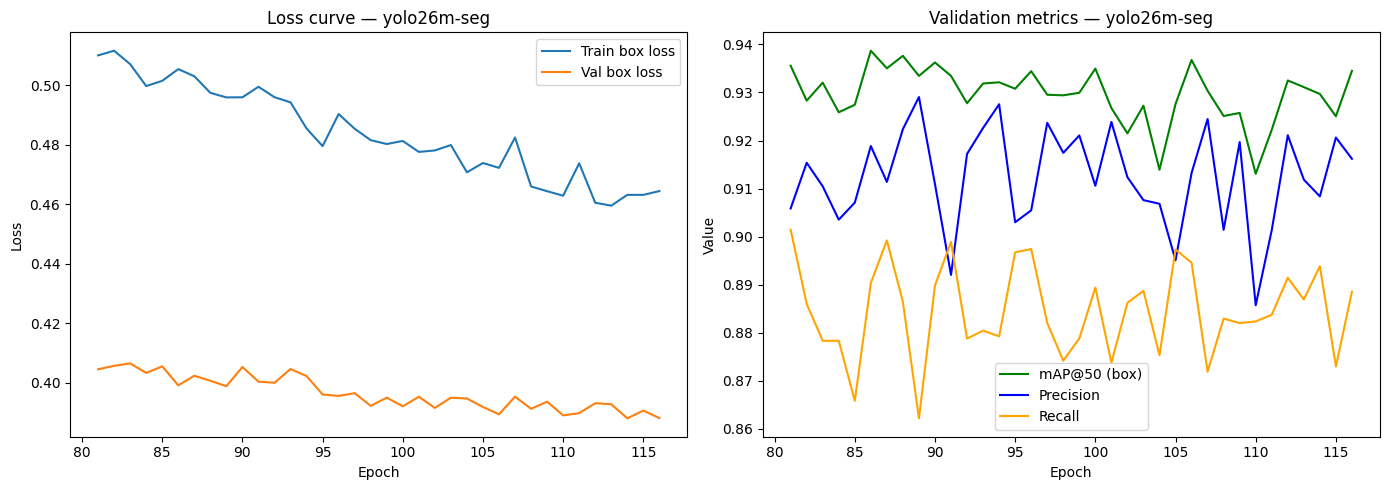

Saved: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET DIENTES/figuras_segmentacion_dientes/curvas_entrenamiento_yolo26m-seg.png


In [11]:
for nombre in VARIANTES:
    results_csv = RUNS_DRIVE / f"results_{nombre}.csv"
    if not results_csv.exists():
        print(f"⚠️ {results_csv} no encontrado — ¿ya entrenaste {nombre}? Saltando.")
        continue

    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(df['epoch'], df['train/box_loss'], label='Train box loss')
    axes[0].plot(df['epoch'], df['val/box_loss'], label='Val box loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss curve — {nombre}')
    axes[0].legend()

    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50 (box)', color='green')
    axes[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
    axes[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='orange')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Value')
    axes[1].set_title(f'Validation metrics — {nombre}')
    axes[1].legend()

    plt.tight_layout()
    out_path = FIGURAS_DRIVE / f"curvas_entrenamiento_{nombre}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print(f"Saved: {out_path}")

## CELL 7 — Evaluation of the three variants on the TEST set (mask metrics, Table 10/11)

Loads each `best.pt` **from Drive**, so this also works standalone, in a
fresh runtime, after all three variants were trained separately.

In [12]:
metricas_por_variante = []

for nombre in VARIANTES:
    ruta_best = MODELOS_DRIVE / f"{nombre}_best.pt"
    if not ruta_best.exists():
        print(f"⚠️ {ruta_best} no encontrado — ¿ya entrenaste {nombre}? Saltando.")
        continue

    print(f"\nEvaluando {nombre} sobre el conjunto de prueba...")
    modelo_best = YOLO(str(ruta_best))
    metrics = modelo_best.val(data=str(DATA_YAML_LOCAL), split="test", imgsz=IMGSZ, device=0)

    n_params = sum(p.numel() for p in modelo_best.model.parameters())
    size_mb = ruta_best.stat().st_size / (1024 * 1024)

    tiempo_path = RUNS_DRIVE / f"tiempo_entrenamiento_{nombre}.txt"
    tiempo_min = float(tiempo_path.read_text().split()[0]) if tiempo_path.exists() else None

    fila = {
        "modelo": nombre,
        "mAP50_box": round(float(metrics.box.map50), 4),
        "mAP50-95_box": round(float(metrics.box.map), 4),
        "precision_box": round(float(metrics.box.mp), 4),
        "recall_box": round(float(metrics.box.mr), 4),
        "mAP50_mask": round(float(metrics.seg.map50), 4),
        "mAP50-95_mask": round(float(metrics.seg.map), 4),
        "precision_mask": round(float(metrics.seg.mp), 4),
        "recall_mask": round(float(metrics.seg.mr), 4),
        "parametros": n_params,
        "tamano_MB": round(size_mb, 2),
        "inferencia_ms": round(metrics.speed.get("inference", 0), 2),
        "tiempo_entrenamiento_min": tiempo_min,
    }
    metricas_por_variante.append(fila)

    tabla_clase = []
    for i, name in enumerate(CLASS_NAMES):
        ap50 = metrics.seg.ap50[i] if i < len(metrics.seg.ap50) else 0
        tabla_clase.append({'Clase': name, 'mAP50_mask': f"{ap50:.3f}"})
    pd.DataFrame(tabla_clase).to_csv(FIGURAS_DRIVE / f"mAP_por_clase_{nombre}.csv", index=False)

df_comp = pd.DataFrame(metricas_por_variante).sort_values("mAP50_mask", ascending=False)
print("\n--- TABLA COMPARATIVA (equivalente a la Tabla 10/11 del artículo, segmentación) ---")
print(df_comp.to_string(index=False))

df_comp.to_csv(RUNS_DRIVE / "comparacion_variantes_segmentacion_dientes.csv", index=False)
df_comp.to_csv(FIGURAS_DRIVE / "comparacion_variantes_segmentacion_dientes.csv", index=False)
print(f"\nGuardada en: {RUNS_DRIVE / 'comparacion_variantes_segmentacion_dientes.csv'}")


Evaluando yolo26n-seg sobre el conjunto de prueba...
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,690,444 parameters, 0 gradients, 9.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 111.6±41.4 MB/s, size: 884.7 KB)
val: Scanning /content/dataset/test/labels... 244 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 244/244 354.0it/s 0.7s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.1s/it 17.7s
                   all        244       3762      0.923      0.897      0.949      0.852      0.925      0.894      0.948      0.841
             1st Molar        211        468      0.939      0.891      0.957      0.857      0.939      0.882      0.956      0.861
          1st Premolar        237        560      0.913      0.904    

## CELL 8 — Final comparison chart (metrics + computational cost)

In [ ]:
df_plot = df_comp.set_index("modelo").reindex(["yolo26n-seg", "yolo26s-seg", "yolo26m-seg"]).dropna(how="all").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot.plot(x="modelo", y=["mAP50_mask", "mAP50-95_mask", "precision_mask", "recall_mask"],
             kind="bar", ax=axes[0])
axes[0].set_title("Performance metrics by variant — tooth segmentation (mask)")
axes[0].set_ylabel("Value")
axes[0].legend(loc="lower right")
axes[0].tick_params(axis="x", rotation=0)

ax2 = axes[1]
ax2.bar(df_plot["modelo"], df_plot["inferencia_ms"], color="#3b82f6")
ax2.set_ylabel("Inference time (ms)", color="#3b82f6")
ax2b = ax2.twinx()
ax2b.plot(df_plot["modelo"], df_plot["tamano_MB"], color="#ef4444", marker="o")
ax2b.set_ylabel("Model size (MB)", color="#ef4444")
axes[1].set_title("Computational cost by variant")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
out_path = FIGURAS_DRIVE / "comparacion_final_segmentacion_dientes.png"
plt.savefig(out_path, dpi=200)
plt.show()
print(f"Guardado: {out_path}")

## CELL 9 — Select the final model

In [ ]:
mejor_variante = df_comp.iloc[0]["modelo"]
mejor_ruta_pesos = MODELOS_DRIVE / f"{mejor_variante}_best.pt"

print(f"Modelo seleccionado (mayor mAP50 de máscara): {mejor_variante}")
print(df_comp[df_comp["modelo"] == mejor_variante].to_string(index=False))
print(f"Pesos: {mejor_ruta_pesos}")

shutil.copy(mejor_ruta_pesos, MODELOS_DRIVE / "modelo_segmentacion_final.pt")
df_comp.to_csv(MODELOS_DRIVE / "comparacion_variantes_segmentacion_dientes.csv", index=False)
shutil.copy(DATA_YAML, MODELOS_DRIVE / "data.yaml")

print(f"\n🏆 Modelo seleccionado copiado también como: {MODELOS_DRIVE / 'modelo_segmentacion_final.pt'}")
print(f"\n📁 Contenido final de {MODELOS_DRIVE}:")
for f in sorted(MODELOS_DRIVE.iterdir()):
    print(" -", f.name)

## CELL 10 — Inference and visualization using images from Drive

In [15]:
from IPython.display import Image, display

test_imgs = [
    '/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/IMAGENES PRUEBA/IMG1.jpeg',
    '/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/IMAGENES PRUEBA/IMG2.jpeg'
]

modelo_final = YOLO(str(MODELOS_DRIVE / "modelo_segmentacion_final.pt"))
results_pred = modelo_final.predict(
    source=test_imgs, save=True,
    project='runs/prueba_segmentacion', name=f'imagenes_prueba_{mejor_variante}',
    conf=0.25, device='cuda:0'
)

print(f"🦷 Predicciones del modelo {mejor_variante}:\n")
pred_imgs = sorted(glob.glob(f'runs/prueba_segmentacion/imagenes_prueba_{mejor_variante}/*'))
for img_path in pred_imgs:
    print(f"📸 {img_path.split('/')[-1]}")
    display(Image(img_path, width=700))


0: 448x640 3 1st Molars, 1 1st Premolar, 1 2nd Molar, 4 2nd Premolars, 1 3rd Molar, 4 Canines, 4 Central Incisors, 4 Lateral Incisors, 14.6ms
1: 448x640 2 1st Molars, 2 1st Premolars, 2 2nd Molars, 2 2nd Premolars, 2 Canines, 2 Central Incisors, 2 Lateral Incisors, 14.6ms
Speed: 3.5ms preprocess, 14.6ms inference, 16.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/runs/prueba_segmentacion/imagenes_prueba_yolo26s-seg
🦷 Predicciones del modelo yolo26s-seg:



## CELL 11 — Markdown table to insert into the article (Table 10/11)

In [17]:
print(df_comp.round(4).to_markdown(index=False))

| modelo      |   mAP50_box |   mAP50-95_box |   precision_box |   recall_box |   mAP50_mask |   mAP50-95_mask |   precision_mask |   recall_mask |   parametros |   tamano_MB |   inferencia_ms |   tiempo_entrenamiento_min |
|:------------|------------:|---------------:|----------------:|-------------:|-------------:|----------------:|-----------------:|--------------:|-------------:|------------:|----------------:|---------------------------:|
| yolo26s-seg |      0.9626 |         0.8793 |          0.9558 |       0.8979 |       0.9616 |          0.8627 |           0.9533 |        0.8972 |     10368436 |       22.28 |           23.98 |                     427.84 |
| yolo26m-seg |      0.9518 |         0.8776 |          0.9196 |       0.9046 |       0.9496 |          0.8564 |           0.9187 |        0.9032 |     23513636 |       51.97 |           33.79 |                     206.34 |
| yolo26n-seg |      0.9489 |         0.8518 |          0.9233 |       0.8974 |       0.9476 |          

## Summary of what is produced after running this pipeline

- `CHECKPOINTS_DRIVE` (`checkpoints_segmentacion_dientes/{variante}/`):
  transient, periodically-synced `last.pt`/`best.pt` used only to survive a
  Colab disconnect mid-training. Auto-deleted once a variant finishes
  successfully.
- `RUNS_DRIVE` (`runs_segmentacion_dientes/`): `results_{variante}.csv`,
  `tiempo_entrenamiento_{variante}.txt`, and the comparison table — saved
  independently per variant, right after each one finishes.
- `FIGURAS_DRIVE` (`figuras_segmentacion_dientes/`): training curves per
  variant, final comparison chart, per-class mAP50 CSVs.
- `MODELOS_DRIVE` (`MODELO DIENTES/`): the **three** `best.pt`/`last.pt`
  files (saved individually as each variant completes, not all at the end),
  the winning model as `modelo_segmentacion_final.pt`, the comparison table,
  and `data.yaml`.

## How to recover from a disconnect

- **Disconnected mid-training of a variant** (e.g. nano at epoch 111): just
  re-run CELL 0–4, then re-run that same variant's cell (5A/5B/5C). It
  detects the checkpoint in `checkpoints_segmentacion_dientes/` and resumes
  from the last synced epoch (at most `CHECKPOINT_EVERY` epochs of rework)
  instead of starting over.
- **Disconnected between variants** (e.g. nano finished, small hadn't
  started): re-run CELL 0–4, then re-run 5B directly. `entrenar_variante`
  sees nano's `best.pt` already in `MODELO DIENTES/` and skips it instead of
  re-training.
- **Everything finished across multiple separate sessions**: CELLs 6–11
  read strictly from Drive, so you can run them in a brand-new runtime
  whenever all three variants show ✅, without needing the training cells'
  in-memory state.

⚠️ Downstream note: update `RUTA_MODELO_SEG` in
`pipeline_asociacion_geometrica.md` to `modelo_segmentacion_final.pt`.